# 04 — Detekcija statističkih anomalija (outliera)

Ova sveska predstavlja **prvi korak istraživačke analize** — detekciju
statističkih odstupanja (outliera) u numeričkim kolonama.

**Metoda:** koristimo neparametarski pristup baziran na **box-plotu** i
**IQR pravilu** (Interquartile Range). Granice za outliere definišemo kao:
- Donja granica: `Q1 − 1.5 × IQR`
- Gornja granica: `Q3 + 1.5 × IQR`

**Zašto neparametarski pristup:** ova metoda ne pretpostavlja normalnu
raspodelu podataka, radi na bilo kakvom obliku raspodele i intuitivno je
razumljiva.

**Ključni princip:** sve analize u ovoj svesci vršimo **isključivo na
trening skupu** (`X_train`). Test skup ostaje netaknut do kraja projekta,
u skladu sa principom sprečavanja *data leakage*.

## 1. Učitavanje trening skupa

Umesto ponavljanja svih prethodnih koraka (učitavanje sirovog CSV-a,
konverzija, split), direktno učitavamo **već pripremljen trening skup**
iz foldera `data/processed/`


In [1]:
# Uvozimo osnovne biblioteke.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# seaborn je nadgradnja matplotlib-a — daje lepše grafike sa manje koda.
import seaborn as sns

# Podešavanja za prikaz.
pd.set_option("display.max_columns", None)

# Podešavanje stila za seaborn grafike — beli background sa mrežom.
sns.set_style("whitegrid")

# Podrazumevana veličina grafika (širina, visina u inčima).
plt.rcParams["figure.figsize"] = (10, 6)

# Učitavamo trening skup atributa (X_train) iz prethodne sveske.
X_train = pd.read_csv("../data/processed/X_train.csv")

print(f"Trening skup učitan: {X_train.shape[0]} redova × {X_train.shape[1]} kolona")

Trening skup učitan: 5625 redova × 19 kolona


## 2. Identifikacija numeričkih kolona za analizu

Box-plot i IQR pravilo primenjuju se **samo na numeričke kolone**. U našem
skupu to su:

- **`tenure`** 
- **`MonthlyCharges`** 
- **`TotalCharges`** 

Kolonu `SeniorCitizen` **ne uključujemo** iako je zapisana kao broj (0/1) —
konceptualno je binarna kategorija, i box-plot na binarnoj vrednosti nema
smisla (dobili bismo samo dve tačke).

In [2]:
# Definišemo listu numeričkih kolona koje analiziramo.
numericke_kolone = ["tenure", "MonthlyCharges", "TotalCharges"]

# Osnovna statistika ovih kolona na trening skupu.
print("Osnovna statistika numeričkih kolona (trening skup):")
X_train[numericke_kolone].describe()

Osnovna statistika numeričkih kolona (trening skup):


,tenure,MonthlyCharges,TotalCharges
count,5625.000000,5625.000000,5625.000000
mean,32.562311,64.999316,2301.839520
std,24.542421,30.108642,2275.586084
min,1.000000,18.400000,18.800000
25%,9.000000,35.800000,413.000000
50%,29.000000,70.600000,1410.250000
75%,56.000000,90.050000,3801.700000
max,72.000000,118.650000,8684.800000


## 3. Analiza kolone `tenure`

`tenure` predstavlja broj meseci koliko je korisnik kod kompanije.
Očekivane vrednosti su od 0 (novi korisnici) do 72 (najstariji, 6 godina).

Analiziramo je kroz dva prikaza:
- **Box-plot** — pokazuje kvartile, medijanu i eventualne outliere
- **Histogram sa krivom** — pokazuje oblik raspodele

Nakon vizuelne inspekcije, numerički ćemo prebrojati outliere pomoću
IQR pravila (`Q1 − 1.5×IQR`, `Q3 + 1.5×IQR`).

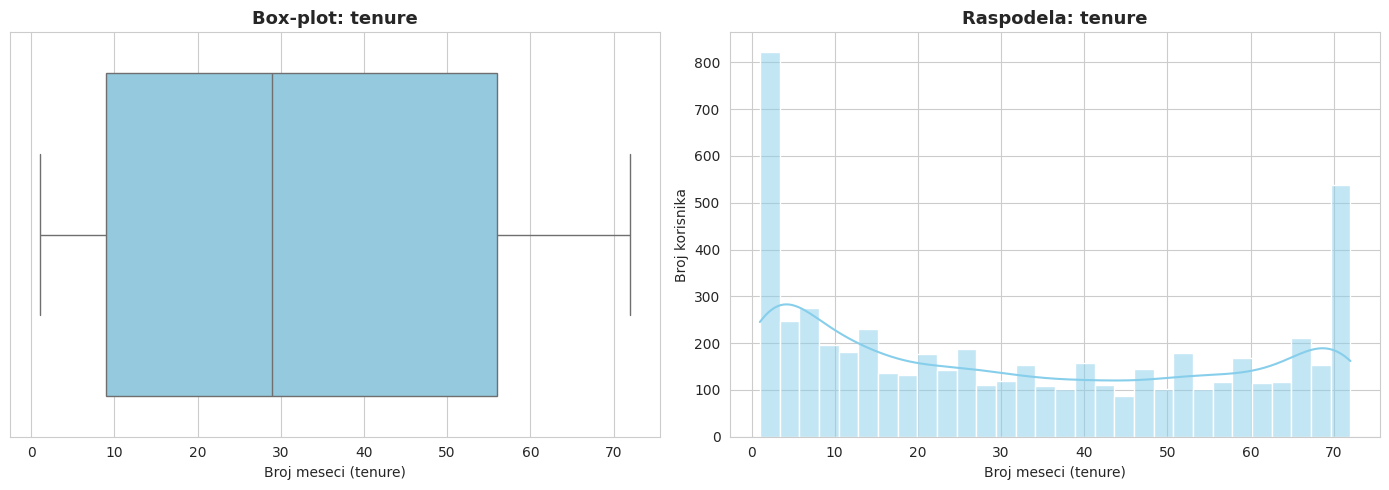

In [3]:
# Pravimo figuru sa dva grafika jedan pored drugog.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.boxplot(x=X_train["tenure"], ax=axes[0], color="skyblue")
axes[0].set_title("Box-plot: tenure", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Broj meseci (tenure)")



sns.histplot(X_train["tenure"], bins=30, kde=True, ax=axes[1], color="skyblue")
axes[1].set_title("Raspodela: tenure", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Broj meseci (tenure)")
axes[1].set_ylabel("Broj korisnika")


plt.tight_layout()

plt.savefig("../images/04_tenure_distribution.png", dpi=100, bbox_inches="tight")

plt.show()

### IQR računica za `tenure`

Nakon vizuelne inspekcije, numerički računamo granice outliera koristeći IQR pravilo.

In [4]:
Q1 = X_train["tenure"].quantile(0.25)
Q3 = X_train["tenure"].quantile(0.75)
IQR = Q3 - Q1

# Granice za outliere.
donja_granica = Q1 - 1.5 * IQR
gornja_granica = Q3 + 1.5 * IQR

# Brojimo koliko vrednosti pada van granica.To cemo uraditi preko uslova i sa funkcijom sum() cemo ih prebrojati.
outliers_mask = (X_train["tenure"] < donja_granica) | (X_train["tenure"] > gornja_granica)
broj_outliera = outliers_mask.sum()

# Ispisujemo rezultate.
print(f"Kolona: tenure")
print(f"  Q1 (25. percentil): {Q1:.2f}")
print(f"  Q3 (75. percentil): {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Donja granica (Q1 - 1.5*IQR): {donja_granica:.2f}")
print(f"  Gornja granica (Q3 + 1.5*IQR): {gornja_granica:.2f}")
print(f"  Broj outliera: {broj_outliera} ({100*broj_outliera/len(X_train):.2f}%)")

Kolona: tenure
  Q1 (25. percentil): 9.00
  Q3 (75. percentil): 56.00
  IQR: 47.00
  Donja granica (Q1 - 1.5*IQR): -61.50
  Gornja granica (Q3 + 1.5*IQR): 126.50
  Broj outliera: 0 (0.00%)


### Tumačenje za `tenure`

**Oblik raspodele:** raspodela je **bimodalna** — dva izražena vrha:
- Prvi vrh na malim vrednostima (~0-5 meseci) — nova pretplata
- Drugi vrh na velikim vrednostima (~70+ meseci) — dugogodišnji korisnici

Ovo ima smisla i sugeriše da postoje dve različite grupe korisnika:
Oni koji se brzo odluče (ili ostanu ili odu), i oni koji su lojalni dugoročno.

**Outlieri:** prema IQR pravilu, **nema outliera** u koloni `tenure`. Granice
[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] su izvan opsega vrednosti (min=0, max=72), pa
ni jedna vrednost ne pada van njih. Ovo je očekivano — `tenure` je prirodno
ograničena kolona bez ekstremnih vrednosti.

Iz ovoga mozemo zakljuciti da nema potrebe za uklanjanjem ili transformacijom outliera u ovoj koloni.

## 4. Analiza kolone `MonthlyCharges`

`MonthlyCharges` predstavlja iznos koji korisnik plaća **mesečno**.
Vrednosti se očekuju u razumnom opsegu (od ~18$ za osnovnu uslugu do
~120$ za najskuplji paket sa svim dodacima).

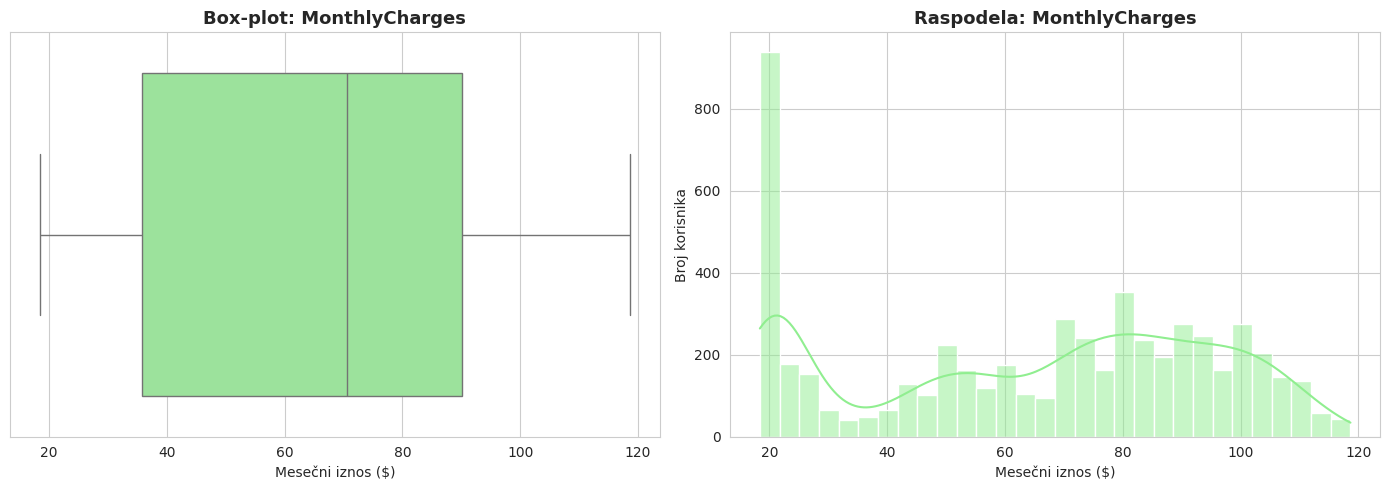

In [5]:
# Ista struktura kao za tenure: box-plot levo, histogram + KDE desno.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box-plot
sns.boxplot(x=X_train["MonthlyCharges"], ax=axes[0], color="lightgreen")
axes[0].set_title("Box-plot: MonthlyCharges", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Mesečni iznos ($)")

# Histogram sa KDE
sns.histplot(X_train["MonthlyCharges"], bins=30, kde=True, ax=axes[1], color="lightgreen")
axes[1].set_title("Raspodela: MonthlyCharges", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Mesečni iznos ($)")
axes[1].set_ylabel("Broj korisnika")

plt.tight_layout()
plt.savefig("../images/04_monthly_charges_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

In [6]:
# IQR računica za MonthlyCharges.
Q1 = X_train["MonthlyCharges"].quantile(0.25)
Q3 = X_train["MonthlyCharges"].quantile(0.75)
IQR = Q3 - Q1

donja_granica = Q1 - 1.5 * IQR
gornja_granica = Q3 + 1.5 * IQR

outliers_mask = (X_train["MonthlyCharges"] < donja_granica) | (X_train["MonthlyCharges"] > gornja_granica)
broj_outliera = outliers_mask.sum()

print(f"Kolona: MonthlyCharges")
print(f"  Q1 (25. percentil): {Q1:.2f}")
print(f"  Q3 (75. percentil): {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Donja granica (Q1 - 1.5*IQR): {donja_granica:.2f}")
print(f"  Gornja granica (Q3 + 1.5*IQR): {gornja_granica:.2f}")
print(f"  Broj outliera: {broj_outliera} ({100*broj_outliera/len(X_train):.2f}%)")

Kolona: MonthlyCharges
  Q1 (25. percentil): 35.80
  Q3 (75. percentil): 90.05
  IQR: 54.25
  Donja granica (Q1 - 1.5*IQR): -45.58
  Gornja granica (Q3 + 1.5*IQR): 171.43
  Broj outliera: 0 (0.00%)


### Tumačenje za `MonthlyCharges`

**Oblik raspodele:** raspodela je **višemodalna** — vidi se nekoliko izraženih
vrhova koji odgovaraju različitim tipovima paketa (osnovni telefonski paket
oko 20$, srednji paketi oko 70-80$, kompletni paketi sa svim dodacima ka 100$+). Vidimo dominantnost u najjeftinijem paketu od 20$ u poredjenju sa ostalim tipovima

**Outlieri:** prema IQR pravilu, **nema outliera** u koloni `MonthlyCharges`.
Sve vrednosti padaju unutar granica [Q1 - 1.5*IQR, Q3 + 1.5*IQR]. Ovo je
očekivano jer su cene paketa ograničene poslovnom logikom (postoji jasan
minimum i maksimum onoga što korisnik može plaćati mesečno).

**Odluka:** nema potrebe za uklanjanjem ili transformacijom.

## 5. Analiza kolone `TotalCharges`

`TotalCharges` predstavlja **ukupan iznos** koji je korisnik platio od
početka korišćenja usluge. Za razliku od `MonthlyCharges`, ova kolona je
**kumulativna** tj. što je korisnik duže kod kompanije, veća joj je vrednost.

Zbog te kumulativne prirode, očekujemo **desno iskošenu raspodelu** : mnogo korisnika sa malim `TotalCharges` (novi ili sa
manjim paketima) i manje njih sa velikim (dugogodišnji korisnici sa
skupim paketima).

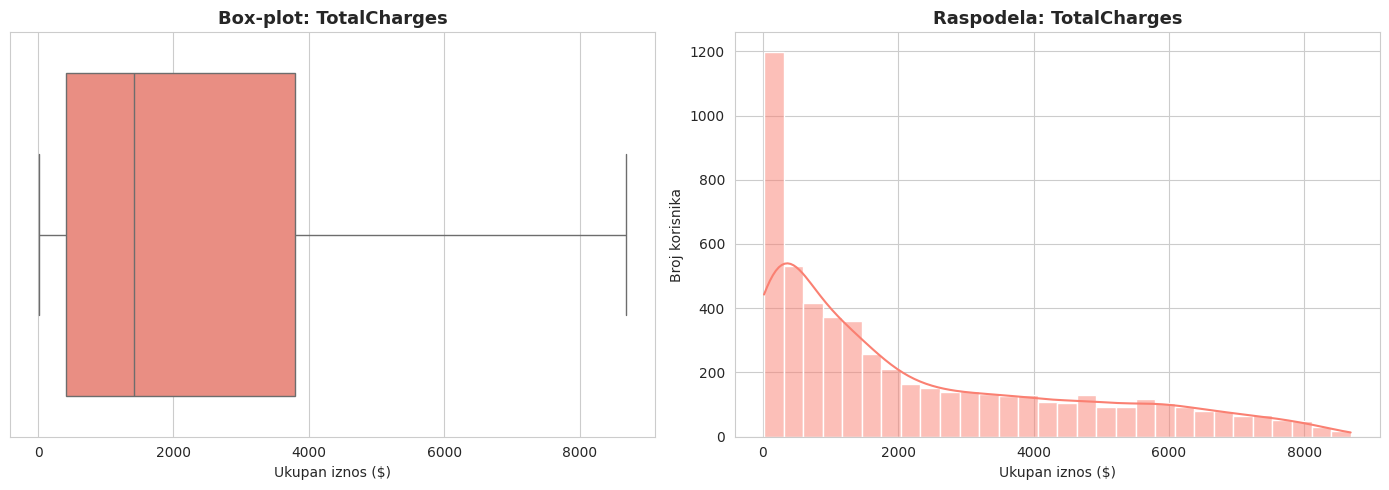

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box-plot
sns.boxplot(x=X_train["TotalCharges"], ax=axes[0], color="salmon")
axes[0].set_title("Box-plot: TotalCharges", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Ukupan iznos ($)")

# Histogram sa KDE
sns.histplot(X_train["TotalCharges"], bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Raspodela: TotalCharges", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Ukupan iznos ($)")
axes[1].set_ylabel("Broj korisnika")

plt.tight_layout()
plt.savefig("../images/04_total_charges_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

In [8]:
# IQR računica za TotalCharges.
Q1 = X_train["TotalCharges"].quantile(0.25)
Q3 = X_train["TotalCharges"].quantile(0.75)
IQR = Q3 - Q1

donja_granica = Q1 - 1.5 * IQR
gornja_granica = Q3 + 1.5 * IQR

outliers_mask = (X_train["TotalCharges"] < donja_granica) | (X_train["TotalCharges"] > gornja_granica)
broj_outliera = outliers_mask.sum()

print(f"Kolona: TotalCharges")
print(f"  Q1 (25. percentil): {Q1:.2f}")
print(f"  Q3 (75. percentil): {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Donja granica (Q1 - 1.5*IQR): {donja_granica:.2f}")
print(f"  Gornja granica (Q3 + 1.5*IQR): {gornja_granica:.2f}")
print(f"  Broj outliera: {broj_outliera} ({100*broj_outliera/len(X_train):.2f}%)")

Kolona: TotalCharges
  Q1 (25. percentil): 413.00
  Q3 (75. percentil): 3801.70
  IQR: 3388.70
  Donja granica (Q1 - 1.5*IQR): -4670.05
  Gornja granica (Q3 + 1.5*IQR): 8884.75
  Broj outliera: 0 (0.00%)


### Tumačenje za `TotalCharges`

**Oblik raspodele:** raspodela je **desno iskošena**, kako je očekivano zbog kumulativne prirode kolone. Većina korisnika ima
male vrednosti (novi ili sa nižim paketima), a broj korisnika sa visokim
vrednostima postepeno opada.

**Outlieri:** prema IQR pravilu, **nema formalnih outliera** — sve vrednosti
padaju unutar granica. Iako raspodela ima dugačak rep udesno, IQR pravilo
ga toleriše zbog samog rasporeda kvartila.

**Napomena:** iskošenost raspodele može biti relevantna za neke modele
(posebno linearne, koji pretpostavljaju normalnost). Kasnije, prilikom pripreme podataka
razmotrićemo eventualnu **log-transformaciju** kolone `TotalCharges` kao
tehniku za smanjivanje iskošenosti.

**Odluka:** nema potrebe za uklanjanjem outliera. Transformacija oblika
je moguća opcija za kasnije.

---

## 6. Zaključak

Detekcija anomalija na trening skupu pokazuje da je skup **statistički čist**:

| Kolona | Q1 | Q3 | IQR | Broj outliera |
|---|---|---|---|---|
| `tenure` | 9.00 | 56.00 | 47.00 | 0 |
| `MonthlyCharges` | 35.80 | 90.05 | 54.25 | 0 |
| `TotalCharges` | 413.00 | 3801.70 | 3388.70 | 0 |

**Ključni nalazi:**

1. **Nijedna numerička kolona ne sadrži outliere** prema IQR pravilu.
2. **`tenure`** ima **bimodalnu raspodelu** (dva vrha — novi i lojalni korisnici).
3. **`MonthlyCharges`** ima **višemodalnu raspodelu** koja odražava
   strukturu paketa (osnovni, srednji, kompletni).
4. **`TotalCharges`** ima **desno iskošenu raspodelu** zbog kumulativne
   prirode kolone.

**Odluke koje smo sada doneli:**
- **Nema uklanjanja podataka** — sve vrednosti su legitimne
- **Kasnije mozemo razmotriti log-transformaciju** za `TotalCharges` smanjenja iskošenosti
